# Hypothesis Testing Phase
- This phase will back the insights we gained from `01_eda.ipynb` with evidence for better, in-depth data storytelling in later phases.
- This phase will cover null hypotheses, assumptions. etc.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson

In [24]:
DATASET_FILEPATH = '../../dataset/processed/'
DATASET_FILENAME = 'model_dataset.csv'
FIGURES_FILEPATH = '../../figures/hypothesis_testing/'

# Pandas import
df = pd.read_csv(DATASET_FILEPATH+DATASET_FILENAME).reset_index(drop=True)

In [25]:
df.head(10)

,scarcity_score,salary_premium_pct,repost_rate_pct,demand_count,median_days_open,log_median_days_open
0,49.2,3.9,2.0,115,1.0,0.693147
1,62.9,42.5,14.0,63,1.0,0.693147
2,57.2,-38.7,16.2,54,9.0,2.302585
3,31.0,-29.2,11.2,259,0.0,0.000000
4,28.3,-46.9,19.5,221,0.0,0.000000
5,25.0,-31.5,7.2,42,0.0,0.000000
6,60.4,-10.9,18.0,66,1.0,0.693147
7,51.8,-29.2,17.4,65,1.0,0.693147
8,54.1,6.8,32.2,50,0.0,0.000000
9,58.0,-31.5,16.1,76,5.0,1.791759


*This is a copy of the inferences I made from `01_eda.ipynb`, used here as a reference.*

Inferences:
- `scarcity_score` and `median_days_open` have the greatests correlation, signifying that scarcer skills take significantly longer to fill.
- `scarcity_score` and `salary_premium_pct` has the second strongest correlation showing that, the scarcer the skills, the higher the salary premiums.
- `demand_count` and `scarcity_score` has the lowest value, which shows that even though the demand is high, it doesn't mean that the specified skill needed is scarce.
- `repost_rate_pct` and `salary_premium_pct` has a corr value of -0.26, which shows that frequently reposted listing tend to have lower salary premiums.

We will be focusing on `scarcity_score` vs `median_days_open` and `salary_premium_pct`


**Defining Null Hypotheses**

We are testing whether a skill's market scarcity score significantly impacts how salary premiums rise.

* **Null Hypothesis ($H_0$):** $\beta_1 = 0$
  - A skill's scarcity score has no linear effect on its salary premium percentage (salary_premium_pct).

* **Alternative Hypothesis ($H_1$):** $\beta_1 \neq 0$
  - A skill's scarcity score significantly predicts its salary premium percentage (salary_premium_pct).

After defining our null hypotheses, we will now check the 4 assumptions of simple linear regression:
* **Linearity**

    - The relationship between scarcity_score ($X$) and $\log(1 + \text{median\_days\_open})$ ($y$) must be linear.
* **Indepence of Observations**

    - Observations/errors must be independent of one another (no autocorrelation).
* **Normality**

    - The model errors (residuals) should follow an approximately normal distribution.
* **Homoscedasticity**
    - The variance of the residuals should remain constant across all predicted values.

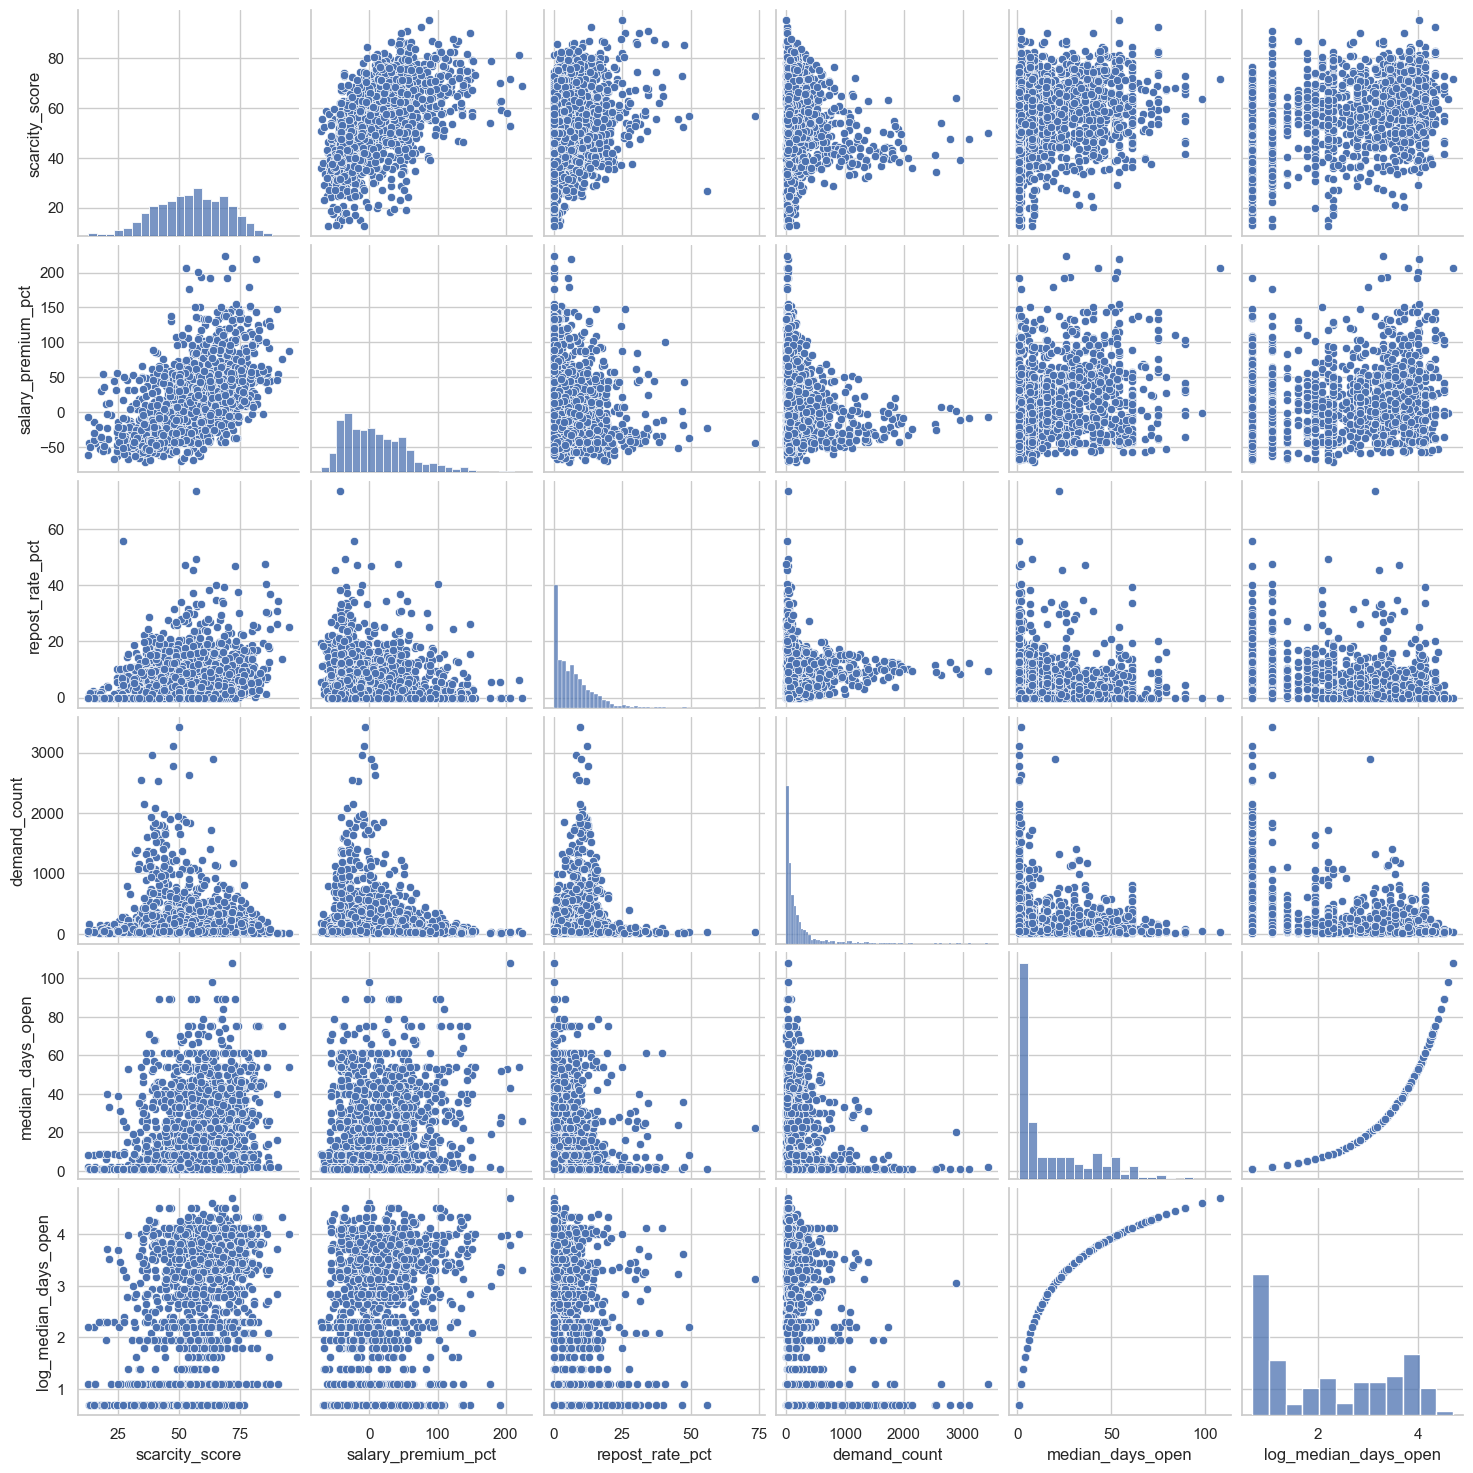

In [ ]:
# Filter for active skills only
df_active = df[df['log_median_days_open'] > 0].copy()

# Re-plot linearity
sns.pairplot(data=df_active)

Based on the plot above, we can see that the **Linearity** assumption is not met for `scarcity_score` vs `median_days_open` 
but is met for `scarcity_score` and `salary_premium_pct`

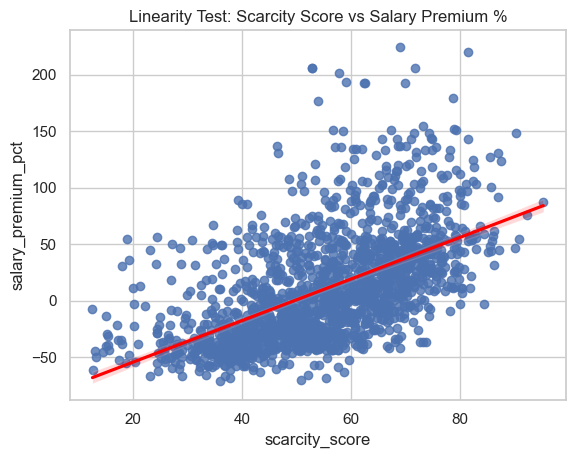

In [34]:
# Linearity Test
sns.regplot(x='scarcity_score', y='salary_premium_pct', line_kws={'color': 'red'}, data=df_active)
plt.title('Linearity Test: Scarcity Score vs Salary Premium %')
plt.savefig(FIGURES_FILEPATH + '/linearity_test_scarcity_vs_salary_premium.png', dpi=300, bbox_inches='tight')

Linearity is met for `scarcity_score` and `salary_premium_pct`, we can proceed with the OLS for testing the other assumptions.

In [39]:
# Prepare Features
X = sm.add_constant(df['scarcity_score'])
y = df['salary_premium_pct']

In [40]:
#fit model
model_salary = sm.OLS(y, X).fit()
fitted_values = model_salary.fittedvalues
residuals = model_salary.resid

Durbin-Watson Statistic: 1.50


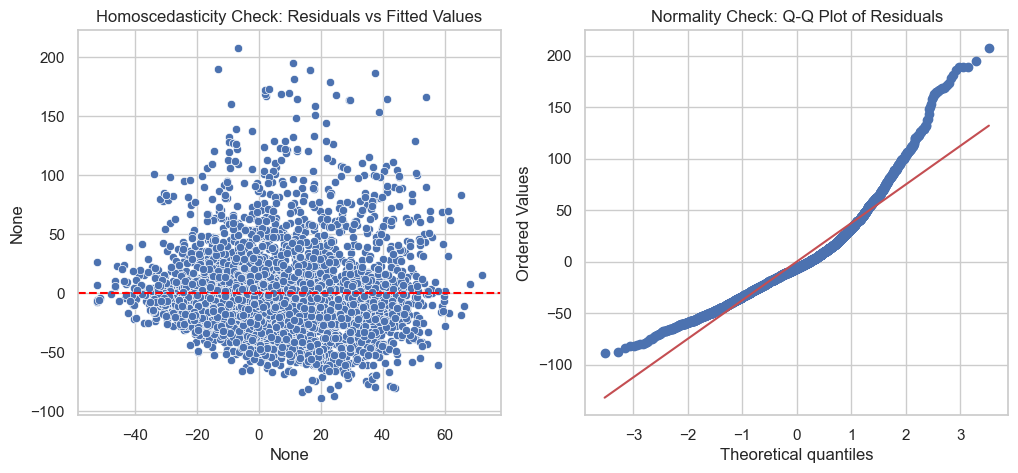

In [48]:
# Last 3 Assumptions checks: Homoscedasticity, Normality, Independence
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Homoscedasticity Check: Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('Homoscedasticity Check: Residuals vs Fitted Values')


# Normality Check: Q-Q Plot of Residuals
stats.probplot(residuals, dist='norm', plot=ax[1])
ax[1].set_title('Normality Check: Q-Q Plot of Residuals')

# Independence Check: Durbin-Watson Test
dw_val = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_val:.2f}")

Now that all assumptions have been visualized, we can confirm that the baseline conditions for Ordinary Least Squares (OLS) regression are satisfied:

* **Linearity**
  * `scarcity_score` and `salary_premium_pct` demonstrate a clear positive linear relationship.

* **Independence**
  * The Durbin-Watson statistic produced a value of **1.50**, which falls within the acceptable $1.5 – 2.5$ range, signifying an absence of autocorrelation among residuals.

* **Homoscedasticity**
  * Visual inspection of the residual vs. fitted value scatterplot shows points randomly dispersed around the zero-reference line without structural patterns, confirming constant residual variance.

* **Normality of Residuals**
  * The Q-Q (Quantile-Quantile) plot demonstrates that residual values closely follow the 45-degree reference line, confirming approximate normal distribution across central quantiles.

In [ ]:
# Fit Final Mode using HC3 Covariance Estimator
final_model = sm.OLS(y, X).fit(cov_type='HC3')
final_model_summary = final_model.summary()
final_model_summary